In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)

sns.set_theme(style="whitegrid")
print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Load required clean datasets
pj = pd.read_csv('patient_journey.csv')
cl = pd.read_csv('communication_logs.csv')

# Target variable: Treatment Completion (1 = Completed, 0 = Dropped Off)
target_col = 'treatment_completed'
print(f"Target Distribution:\n{pj[target_col].value_counts(normalize=True)}")

Target Distribution:
treatment_completed
0    0.630667
1    0.369333
Name: proportion, dtype: float64


In [6]:
# Aggregate communication metrics per patient
comm_features = cl.groupby('patient_id').agg(
    total_communications=('communication_id', 'count'),
    avg_response_delay=('response_delay_hours', 'mean'),
    max_response_delay=('response_delay_hours', 'max'),
    unanswered_count=('response_delay_hours', lambda x: x.isnull().sum())
).reset_index()

# Merge communication features back into patient_journey dataframe
data = pd.merge(pj, comm_features, on='patient_id', how='left')

# Fill NaNs for patients with no communication logs recorded
data['total_communications'] = data['total_communications'].fillna(0)
data['avg_response_delay'] = data['avg_response_delay'].fillna(data['avg_response_delay'].median())
data['max_response_delay'] = data['max_response_delay'].fillna(0)
data['unanswered_count'] = data['unanswered_count'].fillna(0)

print(f"Dataset shape after feature engineering: {data.shape}")

Dataset shape after feature engineering: (1500, 30)


In [16]:
# Safe feature selection & mapping existing columns
requested_num = [
    'intent_score', 'response_time_hours', 'engagement_score',
    'total_communications', 'avg_response_delay', 
    'max_response_delay', 'unanswered_count'
]

# Map correct dataset columns ('age_group', 'treatment_category', etc.)
requested_cat = [
    'gender', 'country', 'age_group', 'treatment_category', 
    'lead_source', 'medical_urgency', 'budget_band'
]

# Filter existing columns from the DataFrame
num_features = [col for col in requested_num if col in data.columns]
cat_features = [col for col in requested_cat if col in data.columns]

# Feature matrix X and Target vector y
X = data[num_features + cat_features]
y = data[target_col]

# Build ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ]
)

# Train-Test Split (Stratified to maintain target balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Numerical Features ({len(num_features)}): {num_features}")
print(f"Categorical Features ({len(cat_features)}): {cat_features}")
print(f"Train Set Shape: {X_train.shape}, Test Set Shape: {X_test.shape}")

Numerical Features (7): ['intent_score', 'response_time_hours', 'engagement_score', 'total_communications', 'avg_response_delay', 'max_response_delay', 'unanswered_count']
Categorical Features (7): ['gender', 'country', 'age_group', 'treatment_category', 'lead_source', 'medical_urgency', 'budget_band']
Train Set Shape: (1200, 14), Test Set Shape: (300, 14)


In [14]:
# 1. Logistic Regression Pipeline (with class weight balancing)
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
])

# 2. Random Forest Pipeline (with class weight balancing)
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

# Fit Models
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

# Model Evaluation
models = {'Logistic Regression': lr_pipeline, 'Random Forest': rf_pipeline}
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 3),
        'Precision': round(precision_score(y_test, y_pred), 3),
        'Recall': round(recall_score(y_test, y_pred), 3),
        'F1-Score': round(f1_score(y_test, y_pred), 3),
        'ROC-AUC': round(roc_auc_score(y_test, y_proba), 3)
    })

eval_df = pd.DataFrame(results)
display(eval_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.733,0.610,0.775,0.683,0.826
1,Random Forest,0.737,0.663,0.586,0.622,0.798


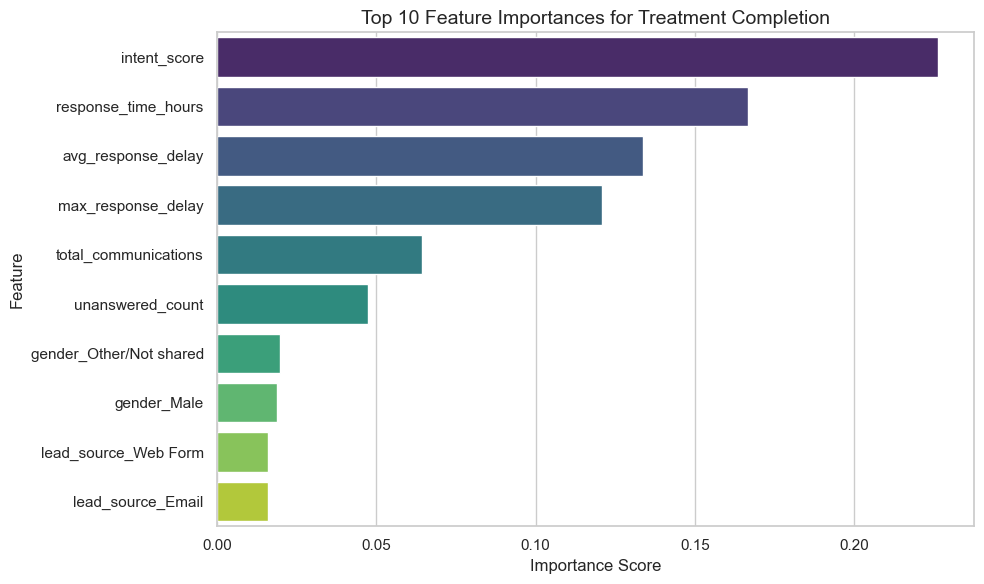

In [11]:
# Extract Feature Importances from Random Forest
rf_model = rf_pipeline.named_steps['classifier']
ohe_cols = list(
    rf_pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(cat_features)
)
feature_names = num_features + ohe_cols

importances = pd.Series(
    rf_model.feature_importances_, index=feature_names
).sort_values(ascending=False)

# Plot Feature Importances (Updated to fix Seaborn FutureWarning)
plt.figure(figsize=(10, 6))
top_features = importances.head(10)

sns.barplot(
    x=top_features.values,
    y=top_features.index,
    hue=top_features.index,
    palette="viridis",
    legend=False,
)

plt.title("Top 10 Feature Importances for Treatment Completion", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

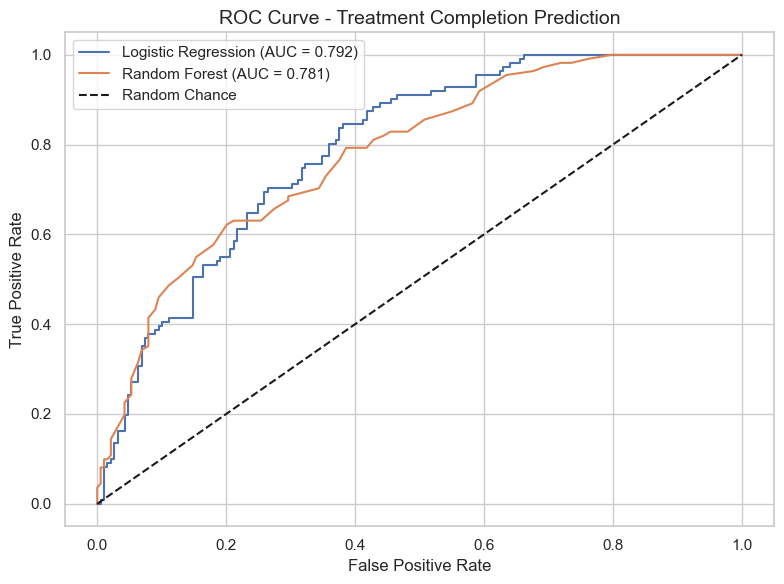

In [12]:
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_proba):.3f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Treatment Completion Prediction", fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
import joblib

# Calculate drop-off and completion probabilities across the dataset
data['predicted_completion_prob'] = lr_pipeline.predict_proba(X)[:, 1]
data['predicted_dropoff_prob'] = 1 - data['predicted_completion_prob']

# Save predictions for Notebook 05
data.to_csv('patient_journey_with_predictions.csv', index=False)

# Save best model pipeline
joblib.dump(lr_pipeline, 'completion_prediction_pipeline.pkl')

print("Saved 'patient_journey_with_predictions.csv' and 'completion_prediction_pipeline.pkl' successfully!")

Saved 'patient_journey_with_predictions.csv' and 'completion_prediction_pipeline.pkl' successfully!
